In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
Train: 5,000 images | Test: 8,000 images
Image shape: torch.Size([3, 96, 96])
Parameters: 1,779,363 | Conv layers: 14


Epoch   5 | Loss: 0.01583 | PSNR: 20.73 dB


Epoch  10 | Loss: 0.01214 | PSNR: 23.82 dB


Epoch  15 | Loss: 0.00983 | PSNR: 25.99 dB


Epoch  20 | Loss: 0.00771 | PSNR: 24.85 dB


...

Epoch  45 | Loss: 0.00692 | PSNR: 23.49 dB


Epoch  50 | Loss: 0.00689 | PSNR: 23.56 dB


Epoch  55 | Loss: 0.00688 | PSNR: 23.54 dB


Epoch  60 | Loss: 0.00687 | PSNR: 23.57 dB

Test Results:
  σ = 0.1 → 25.68 dB
  σ = 0.2 → 24.20 dB
  σ = 0.3 → 18.86 dB


/tmp/ipykernel_55/3867041135.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


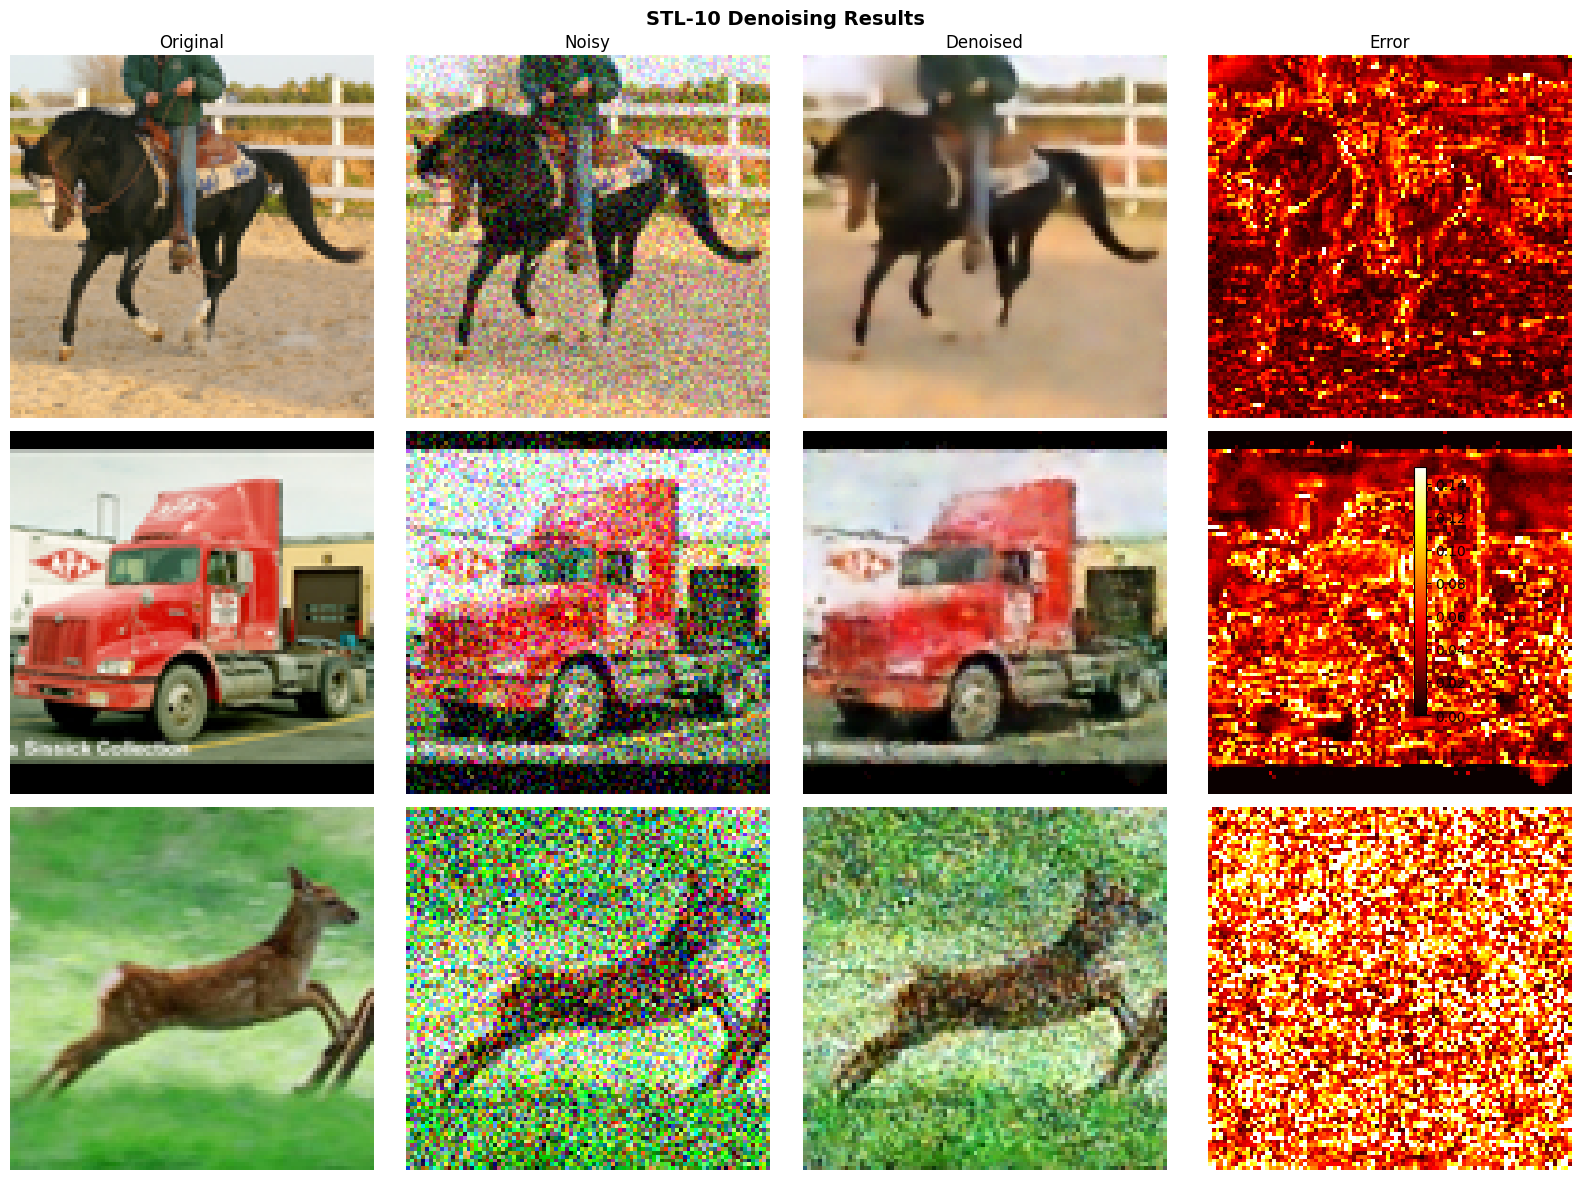

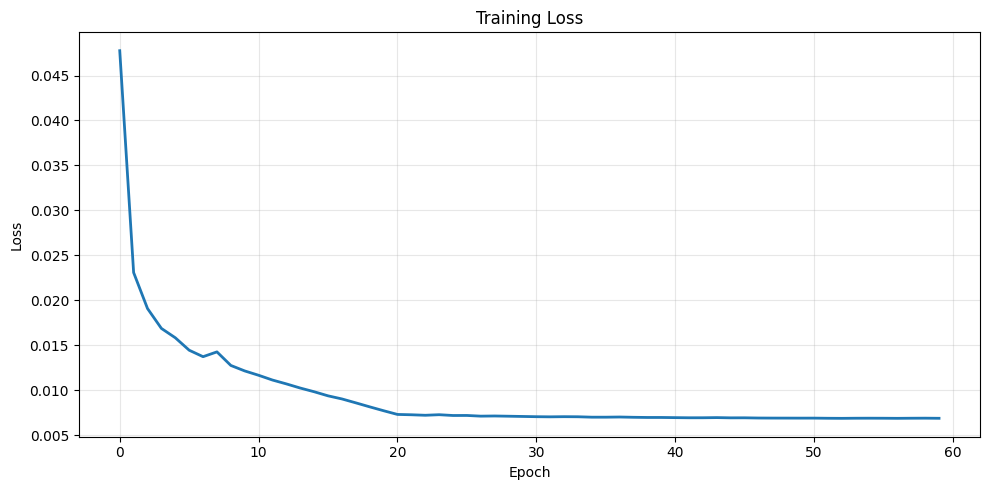

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 64
EPOCHS = 60
LR = 1e-3

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.STL10(root="./data", split='train', download=True, transform=train_transform)
test_set = torchvision.datasets.STL10(root="./data", split='test', download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_set):,} images | Test: {len(test_set):,} images")
print(f"Image shape: {train_set[0][0].shape}")


class LightweightDenoiser(nn.Module):
    def __init__(self, in_ch=3, base_ch=32):
        super().__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch*2, base_ch*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*4),
            nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2)
        
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch*4, base_ch*8, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch*8, base_ch*8, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*8),
            nn.ReLU(inplace=True),
        )
        
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch*8, base_ch*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch*4, base_ch*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*4),
            nn.ReLU(inplace=True),
        )
        
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch*4, base_ch*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(inplace=True),
        )
        
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch*2, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        
        self.out = nn.Conv2d(base_ch, in_ch, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        b = self.bottleneck(self.pool3(e3))
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        noise = self.out(d1)
        return torch.clamp(x - noise, 0., 1.)


model = LightweightDenoiser(in_ch=3, base_ch=32).to(device)
total_convs = sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,} | Conv layers: {total_convs}")


def gradient_loss(pred, target):
    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy_target = target[:, :, 1:, :] - target[:, :, :-1, :]
    dx_target = target[:, :, :, 1:] - target[:, :, :, :-1]
    return F.l1_loss(dy_pred, dy_target) + F.l1_loss(dx_pred, dx_target)


def calculate_psnr(clean, denoised):
    mse = torch.mean((clean - denoised) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse)).item() if mse > 0 else float('inf')


criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

train_losses = []
best_psnr = 0.0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    if epoch < 20:
        noise_std = 0.3 - (epoch / 20) * 0.2
    else:
        noise_std = 0.1
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for images, _ in pbar:
        images = images.to(device)
        noise = noise_std * torch.randn_like(images)
        noisy = torch.clamp(images + noise, 0., 1.)
        
        denoised = model(noisy)
        
        mse_loss = criterion(denoised, images)
        grad_loss = gradient_loss(denoised, images)
        loss = mse_loss + 0.1 * grad_loss
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'noise': f'{noise_std:.3f}'})
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()
    
    if (epoch + 1) % 5 == 0:
        model.eval()
        test_psnr = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                noisy = torch.clamp(images + 0.15 * torch.randn_like(images), 0., 1.)
                denoised = model(noisy)
                mse = F.mse_loss(denoised, images)
                psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
                test_psnr += psnr.item() * images.size(0)
        
        test_psnr /= len(test_set)
        
        if test_psnr > best_psnr:
            best_psnr = test_psnr
            torch.save(model.state_dict(), "best_denoiser.pth")
        
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.5f} | PSNR: {test_psnr:.2f} dB")


model.load_state_dict(torch.load("best_denoiser.pth"))

print("\nTest Results:")
for noise_std in [0.1, 0.2, 0.3]:
    total_psnr = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = torch.clamp(images + noise_std * torch.randn_like(images), 0., 1.)
            denoised = model(noisy)
            mse = F.mse_loss(denoised, images)
            psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
            total_psnr += psnr.item() * images.size(0)
    print(f"  σ = {noise_std} → {total_psnr / len(test_set):.2f} dB")


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
test_iter = iter(test_loader)

for row, noise_std in enumerate([0.1, 0.2, 0.3]):
    images, _ = next(test_iter)
    images = images.to(device)
    noisy = torch.clamp(images + noise_std * torch.randn_like(images), 0., 1.)
    
    with torch.no_grad():
        denoised = model(noisy)
    
    to_np = lambda t: t[0].cpu().numpy().transpose(1, 2, 0)
    orig, nois, den = to_np(images), to_np(noisy), to_np(denoised)
    error = np.abs(den - orig).mean(axis=2)
    
    axes[row, 0].imshow(np.clip(orig, 0, 1))
    axes[row, 0].axis('off')
    if row == 0: axes[row, 0].set_title("Original")
    
    axes[row, 1].imshow(np.clip(nois, 0, 1))
    axes[row, 1].axis('off')
    if row == 0: axes[row, 1].set_title(f"Noisy")
    axes[row, 1].set_ylabel(f"σ={noise_std}")
    
    axes[row, 2].imshow(np.clip(den, 0, 1))
    axes[row, 2].axis('off')
    if row == 0: axes[row, 2].set_title("Denoised")
    
    im = axes[row, 3].imshow(error, cmap='hot', vmin=0, vmax=0.15)
    axes[row, 3].axis('off')
    if row == 0: axes[row, 3].set_title("Error")

plt.colorbar(im, ax=axes[:, 3], fraction=0.046, pad=0.04)
plt.suptitle("STL-10 Denoising Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

GENERATING VISUALIZATIONS


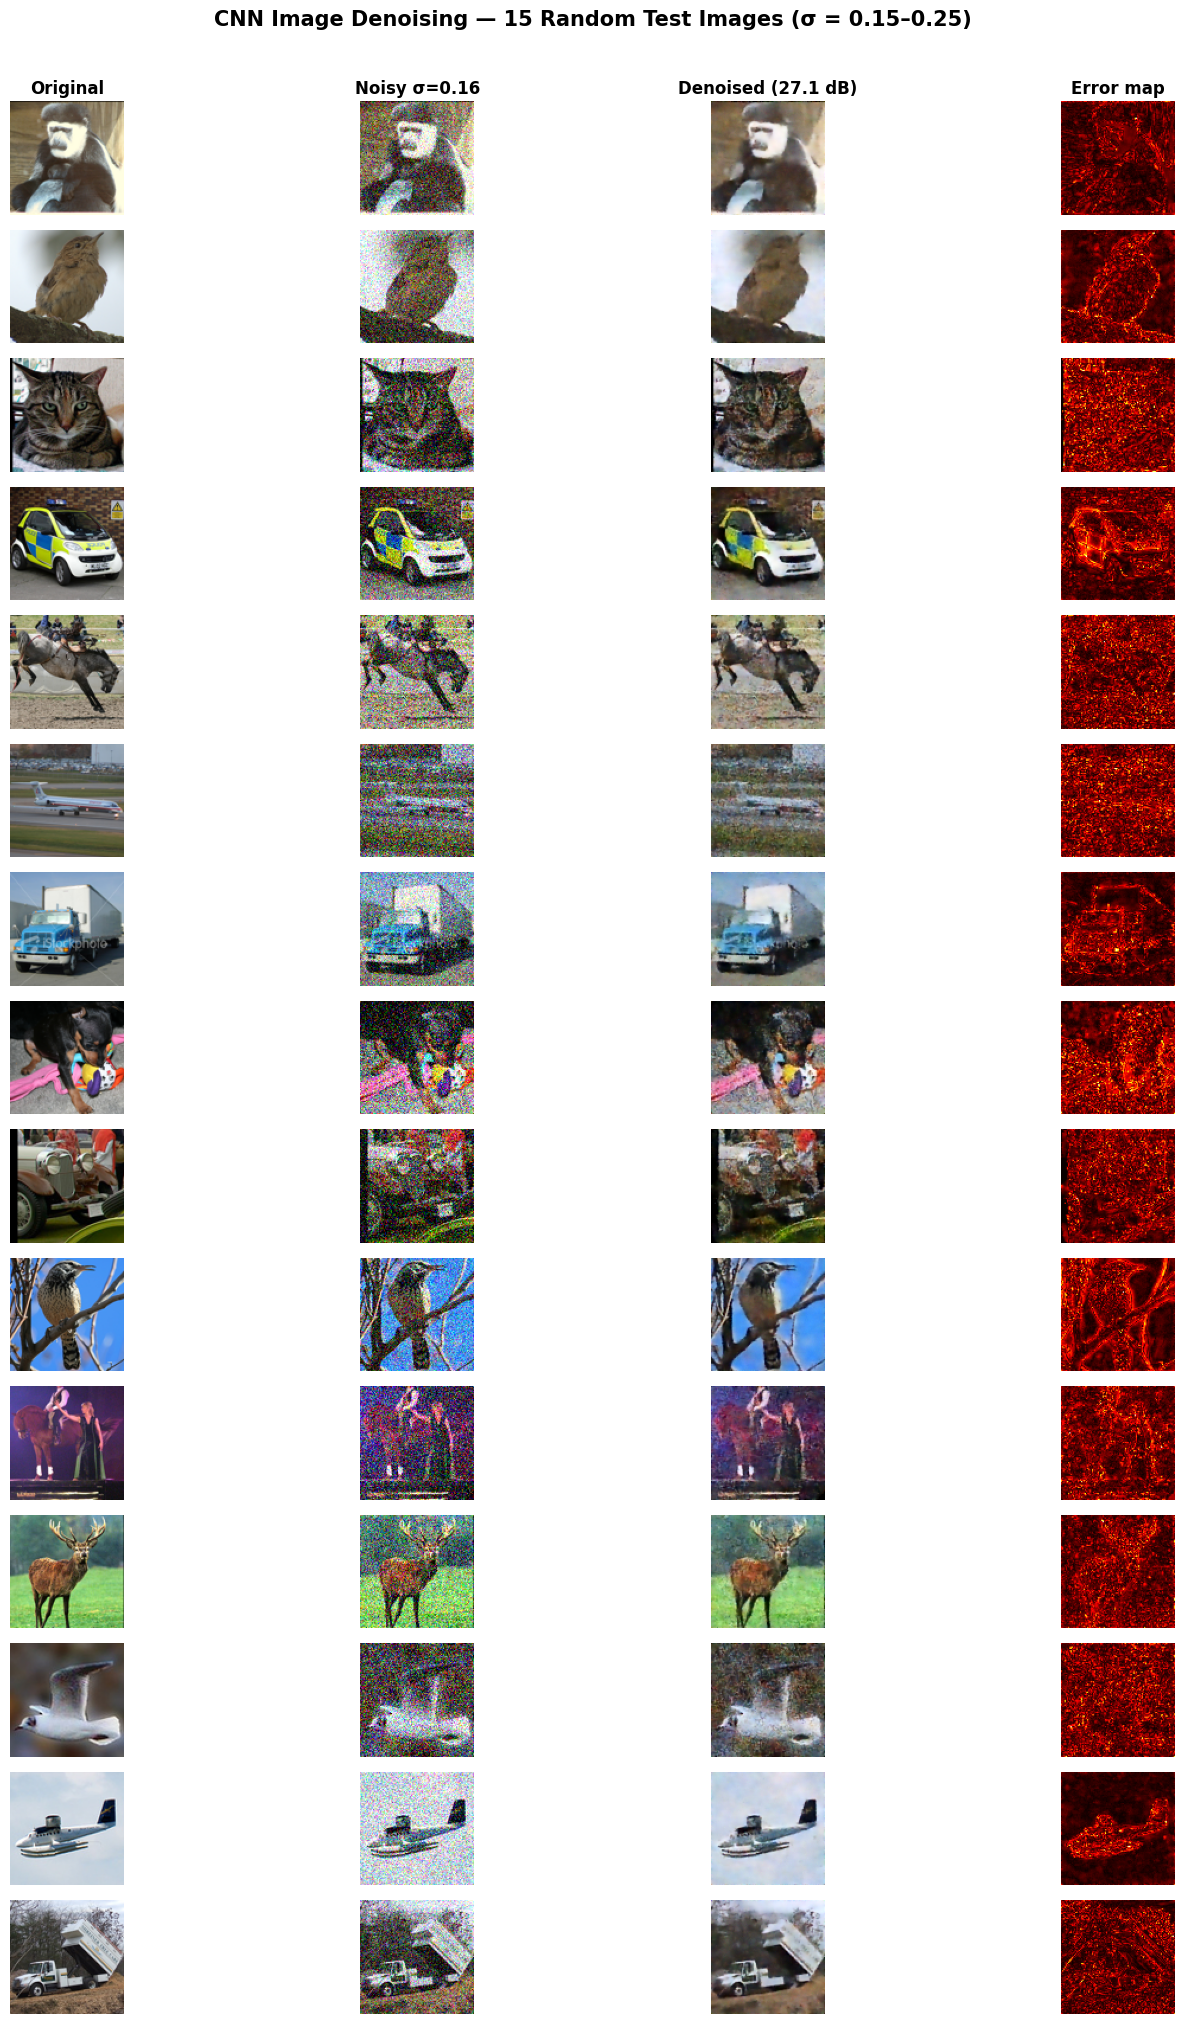

Saved → denoising_results.png


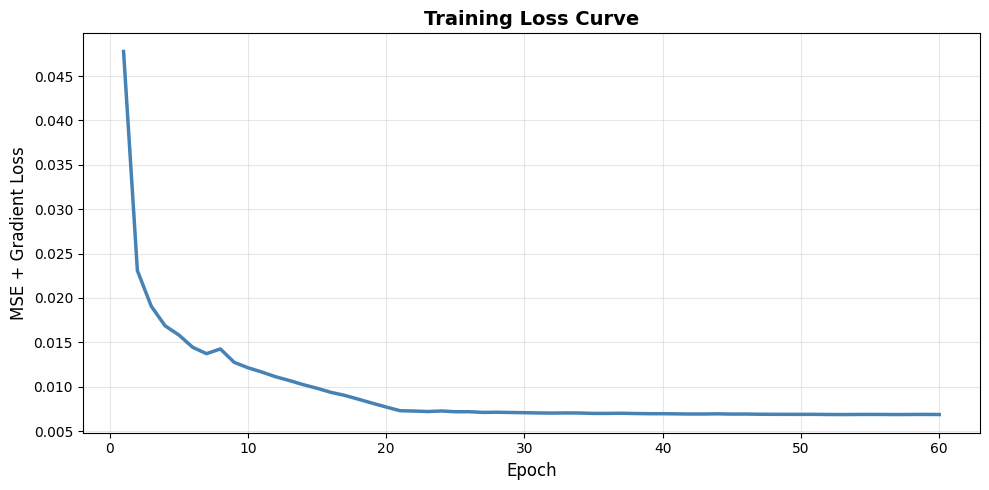

Saved → loss_curve.png


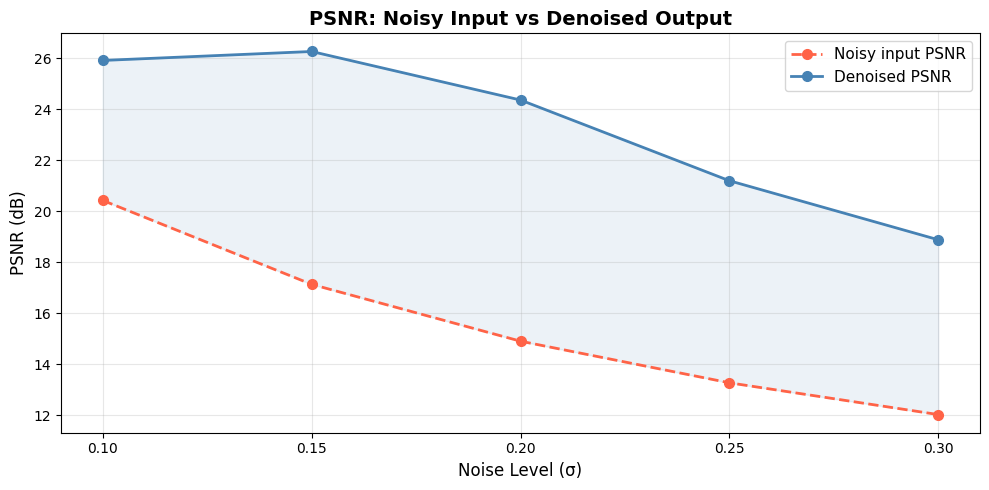

Saved → psnr_curve.png


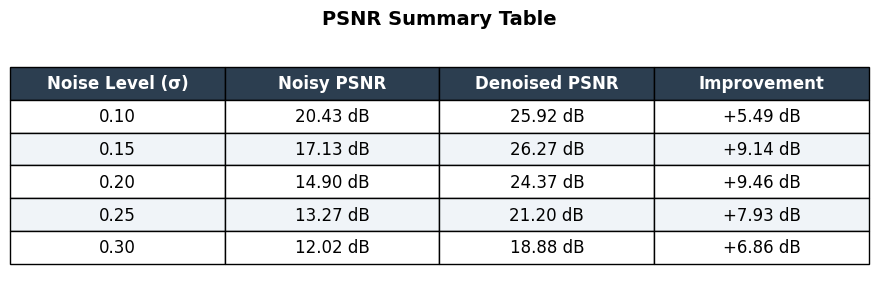

Saved → psnr_table.png


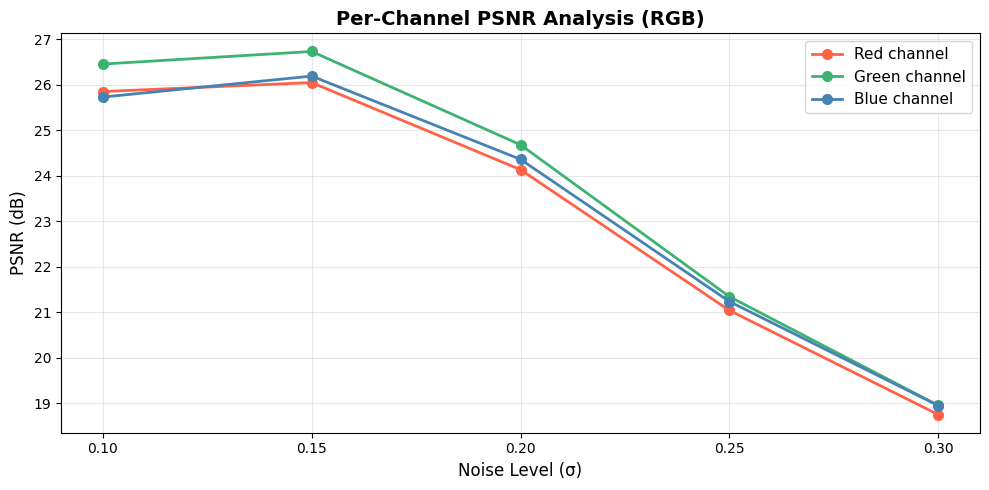

Saved → channel_psnr.png


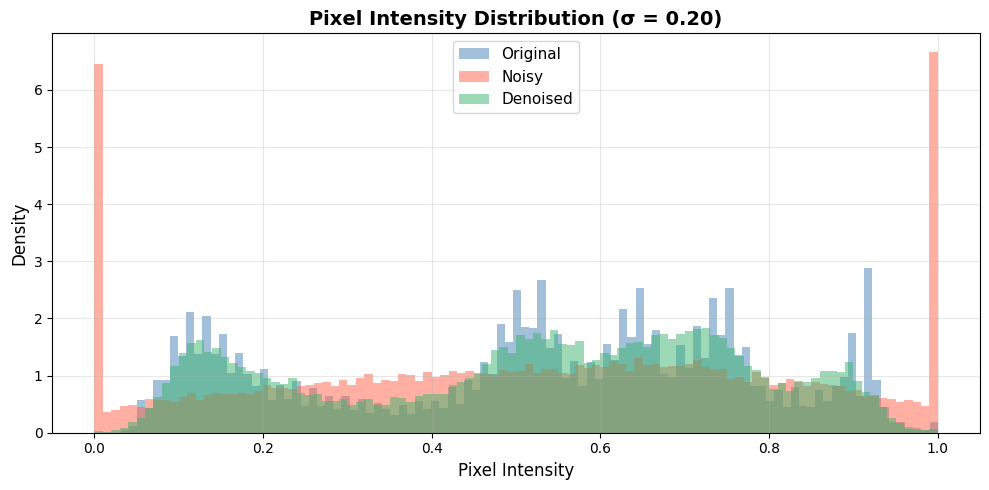

Saved → intensity_histogram.png


In [5]:
print("GENERATING VISUALIZATIONS")
print("="*50)
import random
random_indices = random.sample(range(len(test_set)), 15)
fig, axes = plt.subplots(15, 4, figsize=(16, 20))

for row, idx in enumerate(random_indices):
    image, _ = test_set[idx]
    noise_std = round(random.uniform(0.15, 0.25), 3)

    image = image.unsqueeze(0).to(device)
    noisy = torch.clamp(image + noise_std * torch.randn_like(image), 0., 1.)

    with torch.no_grad():
        denoised = model(noisy)

    to_np = lambda t: t[0].cpu().numpy().transpose(1, 2, 0)
    orig, nois, den = to_np(image), to_np(noisy), to_np(denoised)
    diff = torch.abs(denoised[0] - image[0]).cpu().numpy().transpose(1, 2, 0).mean(axis=2)
    psnr_val = calculate_psnr(image[0], denoised[0])

    for col, (data, title) in enumerate(zip(
        [orig, nois, den, diff],
        ["Original", f"Noisy σ={noise_std}", f"Denoised ({psnr_val:.1f} dB)", "Error map"]
    )):
        ax = axes[row, col]
        ax.imshow(np.clip(data, 0, 1) if col < 3 else data, cmap=None if col < 3 else 'hot')
        if row == 0:
            ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

plt.suptitle("CNN Image Denoising — 15 Random Test Images (σ = 0.15–0.25)", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("denoising_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → denoising_results.png")


plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', linewidth=2.5)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE + Gradient Loss", fontsize=12)
plt.title("Training Loss Curve", fontsize=14, fontweight='bold')
plt.xticks(range(0, EPOCHS + 1, 10))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → loss_curve.png")


noise_levels = [0.10, 0.15, 0.20, 0.25, 0.30]
psnr_scores = []
noisy_psnrs = []

for noise_std in noise_levels:
    total_psnr = 0.0
    total_noisy_psnr = 0.0
    count = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = torch.clamp(images + noise_std * torch.randn_like(images), 0., 1.)
            denoised = model(noisy)

            for i in range(images.size(0)):
                total_psnr += calculate_psnr(images[i], denoised[i])
                total_noisy_psnr += calculate_psnr(images[i], noisy[i])
                count += 1

    psnr_scores.append(total_psnr / count)
    noisy_psnrs.append(total_noisy_psnr / count)

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, noisy_psnrs, 'o--', color='tomato', linewidth=2, markersize=7, label='Noisy input PSNR')
plt.plot(noise_levels, psnr_scores, 'o-', color='steelblue', linewidth=2, markersize=7, label='Denoised PSNR')
plt.fill_between(noise_levels, noisy_psnrs, psnr_scores, alpha=0.1, color='steelblue')
plt.xlabel("Noise Level (σ)", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("PSNR: Noisy Input vs Denoised Output", fontsize=14, fontweight='bold')
plt.xticks(noise_levels)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("psnr_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → psnr_curve.png")


fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

table_data = [
    [f"{s:.2f}", f"{n:.2f} dB", f"{p:.2f} dB", f"+{p-n:.2f} dB"]
    for s, n, p in zip(noise_levels, noisy_psnrs, psnr_scores)
]

table = ax.table(
    cellText=table_data,
    colLabels=["Noise Level (σ)", "Noisy PSNR", "Denoised PSNR", "Improvement"],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2.0)

for j in range(4):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data) + 1):
    for j in range(4):
        table[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')

plt.title("PSNR Summary Table", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("psnr_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → psnr_table.png")


channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['tomato', 'mediumseagreen', 'steelblue']
channel_psnrs = {ch: [] for ch in channel_names}

for noise_std in noise_levels:
    totals = [0.0, 0.0, 0.0]
    count = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = torch.clamp(images + noise_std * torch.randn_like(images), 0., 1.)
            denoised = model(noisy)
            for i in range(images.size(0)):
                for c in range(3):
                    totals[c] += calculate_psnr(images[i, c:c+1], denoised[i, c:c+1])
                count += 1
    for c, ch in enumerate(channel_names):
        channel_psnrs[ch].append(totals[c] / count)

plt.figure(figsize=(10, 5))
for ch, color in zip(channel_names, channel_colors):
    plt.plot(noise_levels, channel_psnrs[ch], 'o-', color=color, linewidth=2, markersize=7, label=f'{ch} channel')
plt.xlabel("Noise Level (σ)", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("Per-Channel PSNR Analysis (RGB)", fontsize=14, fontweight='bold')
plt.xticks(noise_levels)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("channel_psnr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → channel_psnr.png")


image, _ = test_set[0]
image = image.unsqueeze(0).to(device)
noisy = torch.clamp(image + 0.20 * torch.randn_like(image), 0., 1.)
with torch.no_grad():
    denoised = model(noisy)

orig_np = image[0].cpu().numpy().flatten()
noisy_np = noisy[0].cpu().numpy().flatten()
den_np = denoised[0].cpu().numpy().flatten()

plt.figure(figsize=(10, 5))
plt.hist(orig_np, bins=100, alpha=0.5, color='steelblue', label='Original', density=True)
plt.hist(noisy_np, bins=100, alpha=0.5, color='tomato', label='Noisy', density=True)
plt.hist(den_np, bins=100, alpha=0.5, color='mediumseagreen', label='Denoised', density=True)
plt.xlabel("Pixel Intensity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Pixel Intensity Distribution (σ = 0.20)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("intensity_histogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → intensity_histogram.png")